In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import re

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D



In [2]:
import warnings
warnings.filterwarnings("default")

In [3]:
# build data path relative to this script
df0 = pd.read_csv("../data/metrics_masks5_plus_full.csv")

df0 = df0.drop(columns=["image_path", "mask_path","scale_max_used"])
feature_cols = df0.columns[4:]


df0["Fungal_Strain"] = df0["plate"].str.split("_").str[1]
df0["Nitrogen_Level"] = df0["plate"].str.split("_").str[2]

#df0 = df0[df0["Nitrogen_Level"] != "N-1"]



In [4]:
df0.columns 

Index(['plate', 'date', 'view', 'mask_type', 'area_pixels', 'contour_count',
       'perimeter', 'hull_area', 'solidity', 'min_width', 'max_width',
       'rect_angle_deg', 'circularity', 'B_8bit_min', 'B_8bit_max',
       'B_8bit_mean', 'B_8bit_median', 'B_8bit_var', 'G_8bit_min',
       'G_8bit_max', 'G_8bit_mean', 'G_8bit_median', 'G_8bit_var',
       'R_8bit_min', 'R_8bit_max', 'R_8bit_mean', 'R_8bit_median',
       'R_8bit_var', 'Gray_8bit_min', 'Gray_8bit_max', 'Gray_8bit_mean',
       'Gray_8bit_median', 'Gray_8bit_var', 'H_min', 'H_max', 'H_mean',
       'H_median', 'H_var', 'S_min', 'S_max', 'S_mean', 'S_median', 'S_var',
       'V_min', 'V_max', 'V_mean', 'V_median', 'V_var', 'L_min', 'L_max',
       'L_mean', 'L_median', 'L_var', 'A_min', 'A_max', 'A_mean', 'A_median',
       'A_var', 'LabB_min', 'LabB_max', 'LabB_mean', 'LabB_median', 'LabB_var',
       'Fungal_Strain', 'Nitrogen_Level'],
      dtype='object')

In [5]:

views = df0['view'].unique()
mask_types = df0['mask_type'].unique()
dates = df0['date'].unique()[1:] # exclude the first date since some is missing


cols = df0.columns
RGB_traits = [c for c in cols if re.match(r"^[RGB]_8bit_", c)]
HSV_traits = [c for c in cols if re.match(r"^[HSV]_", c)]
LAB_traits = [c for c in cols if re.match(r"^(L_|A_|LabB_)", c)]
Grey_traits = [c for c in cols if c.startswith("Gray_8bit_")]
Ncolor_traits = ['area_pixels', 'circularity',
       'contour_count', 'hull_area', 'max_width', 'min_width', 'perimeter',
       'rect_angle_deg', 'solidity']
trait_sets = {
    "RGB": RGB_traits,
    "HSV": HSV_traits,
    "LAB": LAB_traits,
    "Grey": Grey_traits,
    "Ncolor": Ncolor_traits
}

In [6]:
subset = df0[(df0['view'] =="overhead") & 
             (df0['mask_type'] == "old_growth") & 
             (df0['date'] == "2024-12-24")]

In [7]:
for trait_name, trait_cols in trait_sets.items():
    print(f"Trait set: {trait_name}")
    print(subset[trait_cols].head())

Trait set: RGB
      B_8bit_min  B_8bit_max  B_8bit_mean  B_8bit_median  B_8bit_var  \
3120        96.0       137.0   123.149527          125.0   44.331230   
3122        21.0       104.0    64.233185           69.0  515.406484   
3124        22.0       108.0    65.645107           71.0  502.293843   
3126        22.0       103.0    60.352569           63.0  568.107973   
3128        84.0       133.0   112.041892          113.0   78.657946   

      G_8bit_min  G_8bit_max  G_8bit_mean  G_8bit_median  G_8bit_var  \
3120       128.0       155.0   143.791105          145.0   13.414017   
3122        13.0       107.0    61.473095           66.0  701.452425   
3124        14.0       116.0    64.108989           71.0  710.186673   
3126        15.0       114.0    57.883124           60.0  786.486099   
3128       107.0       151.0   137.011666          138.0   27.067658   

      R_8bit_min  R_8bit_max  R_8bit_mean  R_8bit_median  R_8bit_var  
3120       139.0       161.0   151.059353       

We used nested cross-validation to evaluate classification performance.

In the outer loop, data were split into five folds by holding out one replicate from each strain × nitrogen combination (6 samples total), yielding balanced test sets.

The remaining 24 samples were used for model training. Hyperparameters were tuned within the training set using an inner cross-validation that preserved the same biological stratification.

Final models were trained on all 24 training samples using optimal hyperparameters and evaluated on the held-out test samples.
Performance metrics were averaged across outer folds. (accuracy, confusion matrixs)


we use 3 Linear models and 1 tree models for classification



### Analysis of Nitrogen classification


In [8]:
with open("../results/nitrogen_class/results_nitrogen_update.pkl", "rb") as f:
    results_nitrogen_class = pickle.load(f)

print(type(results_nitrogen_class))   # should be dict

<class 'dict'>


In [9]:
results_nitrogen_class.keys()

dict_keys([('overhead', 'all', '2024-12-21'), ('overhead', 'all', '2024-12-22'), ('overhead', 'all', '2024-12-23'), ('overhead', 'all', '2024-12-24'), ('overhead', 'all', '2024-12-25'), ('overhead', 'all', '2024-12-26'), ('overhead', 'all', '2024-12-27'), ('overhead', 'all', '2024-12-28'), ('overhead', 'all', '2024-12-29'), ('overhead', 'all', '2024-12-30'), ('overhead', 'all', '2024-12-31'), ('overhead', 'plug', '2024-12-21'), ('overhead', 'plug', '2024-12-22'), ('overhead', 'plug', '2024-12-23'), ('overhead', 'plug', '2024-12-24'), ('overhead', 'plug', '2024-12-25'), ('overhead', 'plug', '2024-12-26'), ('overhead', 'plug', '2024-12-27'), ('overhead', 'plug', '2024-12-28'), ('overhead', 'plug', '2024-12-29'), ('overhead', 'plug', '2024-12-30'), ('overhead', 'plug', '2024-12-31'), ('overhead', 'all_plug', '2024-12-21'), ('overhead', 'all_plug', '2024-12-22'), ('overhead', 'all_plug', '2024-12-23'), ('overhead', 'all_plug', '2024-12-24'), ('overhead', 'all_plug', '2024-12-25'), ('overhe

In [10]:
example = results_nitrogen_class.get(('overhead', 'all', '2024-12-21'))

In [11]:
example[0].get('ElasticNet_MultinomialLR')   

,fold,accuracy,balanced_accuracy,best_clf__C,best_clf__l1_ratio
0,1,0.500000,0.500000,3.162278,0.5
1,2,0.666667,0.666667,0.100000,0.1
2,3,0.666667,0.666667,0.100000,0.1
3,4,0.666667,0.666667,3.162278,0.9
4,5,0.333333,0.333333,0.316228,0.3


In [12]:
rows = []
for (view, mask_type, date), v in results_nitrogen_class.items():
    s = v[2]["mean_balanced_accuracy"]   # Series: index=model, values=score

    df_tmp = s.rename("mean_balanced_accuracy").reset_index()
    df_tmp.columns = ["model", "mean_balanced_accuracy"]

    df_tmp["view"] = view
    df_tmp["mask_type"] = mask_type
    df_tmp["date"] = date

    rows.append(df_tmp)

df_scores_fungus_class = pd.concat(rows, ignore_index=True)

# optional: reorder columns
df_scores_fungus_class = df_scores_fungus_class[["view", "mask_type", "date", "model", "mean_balanced_accuracy"]]

In [13]:
df_scores_fungus_class['mean_balanced_accuracy'].describe()

count    550.000000
mean       0.789212
std        0.121969
min        0.466667
25%        0.700000
50%        0.783333
75%        0.900000
max        1.000000
Name: mean_balanced_accuracy, dtype: float64

In [14]:
df_scores_fungus_class.head()

,view,mask_type,date,model,mean_balanced_accuracy
0,overhead,all,2024-12-21,RandomForest,0.733333
1,overhead,all,2024-12-21,Lasso_MultinomialLR,0.633333
2,overhead,all,2024-12-21,ShrinkageLDA,0.600000
3,overhead,all,2024-12-21,PLSDA_PLSScores_plus_LR,0.600000
4,overhead,all,2024-12-21,ElasticNet_MultinomialLR,0.566667


In [15]:
df_scores_fungus_class['model'].unique()

array(['RandomForest', 'Lasso_MultinomialLR', 'ShrinkageLDA',
       'PLSDA_PLSScores_plus_LR', 'ElasticNet_MultinomialLR'],
      dtype=object)

In [16]:
model_label_map = {
    "ElasticNet_MultinomialLR": "ElasticNet",
    "Lasso_MultinomialLR": "Lasso",
    "ShrinkageLDA": "LDA (shrinkage)",
    "RandomForest": "Random Forest",
    "PLSDA_PLSScores_plus_LR": "PLS-DA + LR",
}

df_scores_fungus_class["model_label"] = (
    df_scores_fungus_class["model"]
    .map(model_label_map)
)

In [17]:
mask_order = ["all", "plug", "all_plug", "new_growth", "old_growth"]
view_order = ["raw", "overhead"]



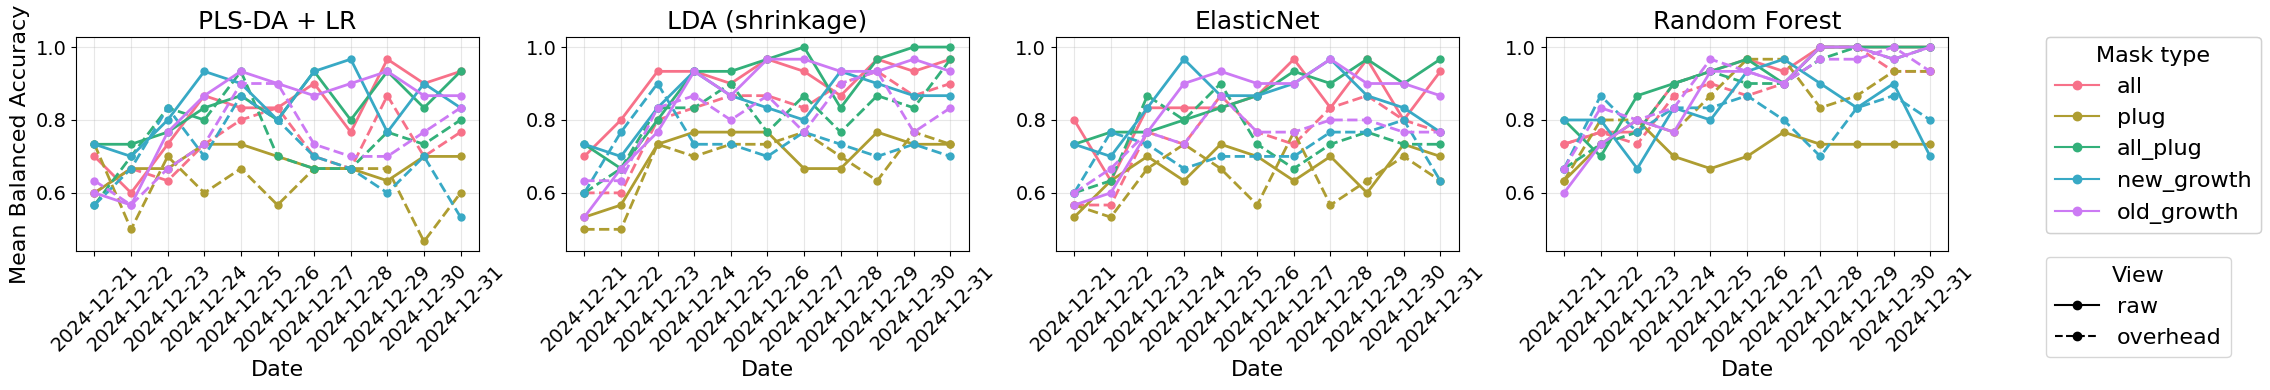

In [18]:
model_order = ["PLS-DA + LR","LDA (shrinkage)", "ElasticNet","Random Forest"]
df_scores_fungus_class = df_scores_fungus_class[df_scores_fungus_class["model_label"].isin(model_order)]

FONTSIZE = 16

mask_order = ["all", "plug", "all_plug", "new_growth", "old_growth"]
mask_palette = dict(zip(mask_order, sns.color_palette("husl", len(mask_order))))

view_order = ["raw", "overhead"]
view_linestyles = {"raw": "-", "overhead": "--"}


metrics = df_scores_fungus_class.columns[df_scores_fungus_class.columns.str.startswith("mean_")] 

n_rows = len(metrics)
n_cols = len(model_order)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4*n_rows),
    sharex=True
)

if n_rows == 1:
    axes = [axes]
if n_cols == 1:
    axes = [[ax] for ax in axes]

for i, metric in enumerate(metrics):
    y_min = df_scores_fungus_class[metric].min()
    y_max = df_scores_fungus_class[metric].max()

    margin = (y_max - y_min) * 0.05
    y_min -= margin
    y_max += margin

    for j, model in enumerate(model_order):

        ax = axes[i][j]

        subset = df_scores_fungus_class[df_scores_fungus_class["model_label"] == model]
        for mask_type in mask_order:
            mask_subset = subset[subset["mask_type"] == mask_type]

            for view in view_order:
                view_subset = mask_subset[mask_subset["view"] == view]

                if not view_subset.empty:
                    view_subset = view_subset.sort_values("date")

                    ax.plot(
                        view_subset["date"],
                        view_subset[metric],
                        marker="o",
                        color=mask_palette[mask_type],
                        linestyle=view_linestyles[view],
                        linewidth=2,
                        markersize=5
                    )
        ax.set_ylim(y_min, y_max)
        if i == 0:
            ax.set_title(model, fontsize=FONTSIZE + 2)

        if j == 0:
            ax.set_ylabel(metric.replace("_", " ").title(), fontsize=FONTSIZE)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Date", fontsize=FONTSIZE)
        ax.tick_params(axis='x', rotation=45, labelsize=FONTSIZE - 2)
        ax.tick_params(axis='y', labelsize=FONTSIZE - 2)
        ax.grid(True, alpha=0.3)

mask_legend = [
    Line2D([0], [0],
           color=mask_palette[m],
           linestyle='-',
           marker='o',
           label=m)
    for m in mask_order
]

view_legend = [
    Line2D([0], [0],
           color='black',
           linestyle=view_linestyles[v],
           marker='o',
           label=v)
    for v in view_order
]

legend1 = fig.legend(
    handles=mask_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.65),
    title="Mask type",
    fontsize=FONTSIZE,
    title_fontsize=FONTSIZE
)

legend2 = fig.legend(
    handles=view_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.22),
    title="View",
    fontsize=FONTSIZE,
    title_fontsize=FONTSIZE
)

fig.add_artist(legend1)

plt.tight_layout()
plt.savefig("../results/nitrogen_class/classification_performance_over_time_nitrogen.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()


### N10-N100

In [19]:
with open("../results/nitrogen_class/results_nitrogen_binary_update.pkl", "rb") as f:
    results_nitrogen_class_binary = pickle.load(f)

print(type(results_nitrogen_class_binary))   # should be dict

<class 'dict'>


In [20]:
rows = []
for (view, mask_type, date), v in results_nitrogen_class_binary.items():
    s = v[2]["mean_balanced_accuracy"]   # Series: index=model, values=score

    df_tmp = s.rename("mean_balanced_accuracy").reset_index()
    df_tmp.columns = ["model", "mean_balanced_accuracy"]

    df_tmp["view"] = view
    df_tmp["mask_type"] = mask_type
    df_tmp["date"] = date

    rows.append(df_tmp)

df_scores_nitrogen_class_binary = pd.concat(rows, ignore_index=True)

# optional: reorder columns
df_scores_nitrogen_class_binary = df_scores_nitrogen_class_binary[["view", "mask_type", "date", "model", "mean_balanced_accuracy"]]

In [22]:
model_label_map = {
    "ElasticNet_MultinomialLR": "ElasticNet",
    "Lasso_MultinomialLR": "Lasso",
    "ShrinkageLDA": "LDA (shrinkage)",
    "RandomForest": "Random Forest",
    "PLSDA_PLSScores_plus_LR": "PLS-DA + LR",
}

df_scores_nitrogen_class_binary["model_label"] = (
    df_scores_nitrogen_class_binary["model"]
    .map(model_label_map)
)

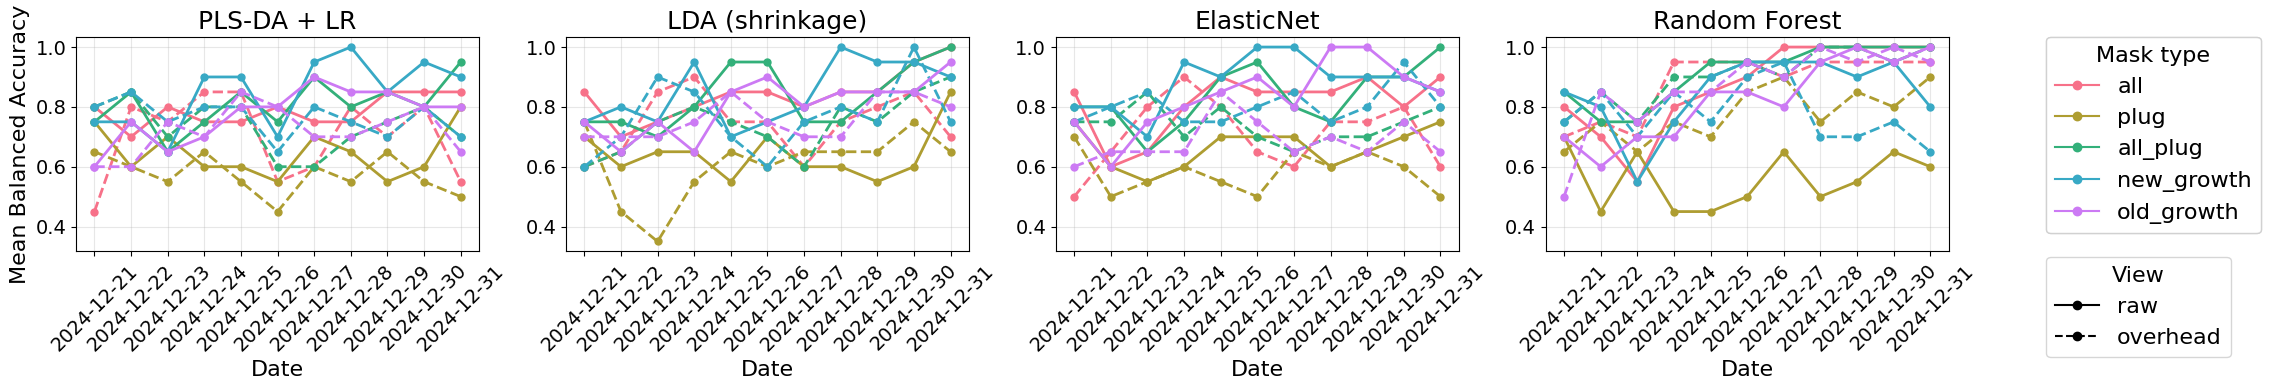

In [24]:
FONTSIZE = 16

mask_order = ["all", "plug", "all_plug", "new_growth", "old_growth"]
mask_palette = dict(zip(mask_order, sns.color_palette("husl", len(mask_order))))

view_order = ["raw", "overhead"]
view_linestyles = {"raw": "-", "overhead": "--"}


metrics = df_scores_nitrogen_class_binary.columns[df_scores_nitrogen_class_binary.columns.str.startswith("mean_")] 
df_scores_nitrogen_class_binary = df_scores_nitrogen_class_binary[df_scores_nitrogen_class_binary["model_label"].isin(model_order)]


n_rows = len(metrics)
n_cols = len(model_order)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4*n_rows),
    sharex=True
)

if n_rows == 1:
    axes = [axes]
if n_cols == 1:
    axes = [[ax] for ax in axes]

for i, metric in enumerate(metrics):
    y_min = df_scores_nitrogen_class_binary[metric].min()
    y_max = df_scores_nitrogen_class_binary[metric].max()

    margin = (y_max - y_min) * 0.05
    y_min -= margin
    y_max += margin

    for j, model in enumerate(model_order):

        ax = axes[i][j]

        subset = df_scores_nitrogen_class_binary[df_scores_nitrogen_class_binary["model_label"] == model]
        for mask_type in mask_order:
            mask_subset = subset[subset["mask_type"] == mask_type]

            for view in view_order:
                view_subset = mask_subset[mask_subset["view"] == view]

                if not view_subset.empty:
                    view_subset = view_subset.sort_values("date")

                    ax.plot(
                        view_subset["date"],
                        view_subset[metric],
                        marker="o",
                        color=mask_palette[mask_type],
                        linestyle=view_linestyles[view],
                        linewidth=2,
                        markersize=5
                    )
        ax.set_ylim(y_min, y_max)
        if i == 0:
            ax.set_title(model, fontsize=FONTSIZE + 2)

        if j == 0:
            ax.set_ylabel(metric.replace("_", " ").title(), fontsize=FONTSIZE)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Date", fontsize=FONTSIZE)
        ax.tick_params(axis='x', rotation=45, labelsize=FONTSIZE - 2)
        ax.tick_params(axis='y', labelsize=FONTSIZE - 2)
        ax.grid(True, alpha=0.3)

mask_legend = [
    Line2D([0], [0],
           color=mask_palette[m],
           linestyle='-',
           marker='o',
           label=m)
    for m in mask_order
]

view_legend = [
    Line2D([0], [0],
           color='black',
           linestyle=view_linestyles[v],
           marker='o',
           label=v)
    for v in view_order
]

legend1 = fig.legend(
    handles=mask_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.65),
    title="Mask type",
    fontsize=FONTSIZE,
    title_fontsize=FONTSIZE
)

legend2 = fig.legend(
    handles=view_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.22),
    title="View",
    fontsize=FONTSIZE,
    title_fontsize=FONTSIZE
)

fig.add_artist(legend1)

plt.tight_layout()
plt.savefig("../results/nitrogen_class/classification_performance_over_time_nitrogen_binary.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()


# color space

In [26]:
with open("../results/nitrogen_class/results_nitrogen_color_update.pkl", "rb") as f:
    results_nitrogen_class_color = pickle.load(f)

print(type(results_nitrogen_class_color))   # should be dict

<class 'dict'>


In [27]:
results_nitrogen_class_color.keys()

dict_keys([('overhead', 'all', '2024-12-21'), ('overhead', 'all', '2024-12-22'), ('overhead', 'all', '2024-12-23'), ('overhead', 'all', '2024-12-24'), ('overhead', 'all', '2024-12-25'), ('overhead', 'all', '2024-12-26'), ('overhead', 'all', '2024-12-27'), ('overhead', 'all', '2024-12-28'), ('overhead', 'all', '2024-12-29'), ('overhead', 'all', '2024-12-30'), ('overhead', 'all', '2024-12-31'), ('overhead', 'plug', '2024-12-21'), ('overhead', 'plug', '2024-12-22'), ('overhead', 'plug', '2024-12-23'), ('overhead', 'plug', '2024-12-24'), ('overhead', 'plug', '2024-12-25'), ('overhead', 'plug', '2024-12-26'), ('overhead', 'plug', '2024-12-27'), ('overhead', 'plug', '2024-12-28'), ('overhead', 'plug', '2024-12-29'), ('overhead', 'plug', '2024-12-30'), ('overhead', 'plug', '2024-12-31'), ('overhead', 'all_plug', '2024-12-21'), ('overhead', 'all_plug', '2024-12-22'), ('overhead', 'all_plug', '2024-12-23'), ('overhead', 'all_plug', '2024-12-24'), ('overhead', 'all_plug', '2024-12-25'), ('overhe

In [28]:
results_nitrogen_class_color.get((('overhead', 'old_growth', '2024-12-24')))

{'RGB': ({'ElasticNet_MultinomialLR':    fold  accuracy  balanced_accuracy  best_clf__C  best_clf__l1_ratio
   0     1  0.833333           0.833333    10.000000                 0.9
   1     2  0.833333           0.833333   100.000000                 0.9
   2     3  0.666667           0.666667    31.622777                 0.9
   3     4  0.833333           0.833333    10.000000                 0.5
   4     5  0.666667           0.666667     3.162278                 0.1,
   'Lasso_MultinomialLR':    fold  accuracy  balanced_accuracy  best_clf__C
   0     1  0.833333           0.833333    10.000000
   1     2  0.666667           0.666667     3.162278
   2     3  0.833333           0.833333    10.000000
   3     4  0.500000           0.500000    10.000000
   4     5  0.833333           0.833333    10.000000,
   'ShrinkageLDA':    fold  accuracy  balanced_accuracy best_lda__shrinkage best_lda__solver
   0     1  0.833333           0.833333                auto             lsqr
   1     2  0.

In [29]:
rows = []

for (view, mask_type, date), v in results_nitrogen_class_color.items():
    for color_space in v.keys():  
        s = v.get(color_space)[2]["mean_balanced_accuracy"]

        df_tmp = s.rename("mean_balanced_accuracy").reset_index()
        df_tmp.columns = ["model", "mean_balanced_accuracy"]

        df_tmp["view"] = view
        df_tmp["mask_type"] = mask_type
        df_tmp["date"] = date
        df_tmp["color_space"] = color_space

        rows.append(df_tmp)

df_scores_nitrogen_class_color = pd.concat(rows, ignore_index=True)

In [30]:
df_scores_nitrogen_class_color


,model,mean_balanced_accuracy,view,mask_type,date,color_space
0,RandomForest,0.600000,overhead,all,2024-12-21,RGB
1,Lasso_MultinomialLR,0.500000,overhead,all,2024-12-21,RGB
2,ShrinkageLDA,0.466667,overhead,all,2024-12-21,RGB
3,ElasticNet_MultinomialLR,0.433333,overhead,all,2024-12-21,RGB
4,PLSDA_PLSScores_plus_LR,0.400000,overhead,all,2024-12-21,RGB
...,...,...,...,...,...,...
2745,RandomForest,0.533333,raw,old_growth,2024-12-31,Ncolor
2746,ElasticNet_MultinomialLR,0.500000,raw,old_growth,2024-12-31,Ncolor
2747,PLSDA_PLSScores_plus_LR,0.466667,raw,old_growth,2024-12-31,Ncolor
2748,ShrinkageLDA,0.400000,raw,old_growth,2024-12-31,Ncolor


In [31]:
models = df_scores_nitrogen_class_color["model"].unique()
color_types = df_scores_nitrogen_class_color["color_space"].unique()



n_rows = len(models)
n_cols = len(color_types)


In [32]:
mask_order = ["all", "plug", "all_plug", "new_growth", "old_growth"]
mask_palette = dict(zip(mask_order, sns.color_palette("husl", len(mask_order))))

view_order = ["raw", "overhead"]
view_linestyles = {"raw": "-", "overhead": "--"}

In [35]:
models

array(['RandomForest', 'Lasso_MultinomialLR', 'ShrinkageLDA',
       'ElasticNet_MultinomialLR', 'PLSDA_PLSScores_plus_LR'],
      dtype=object)

In [36]:
model_order

['PLS-DA + LR', 'LDA (shrinkage)', 'ElasticNet', 'Random Forest']

In [37]:
df_scores_nitrogen_class_color["model_label"] = (
    df_scores_nitrogen_class_color["model"]
    .map(model_label_map)
)

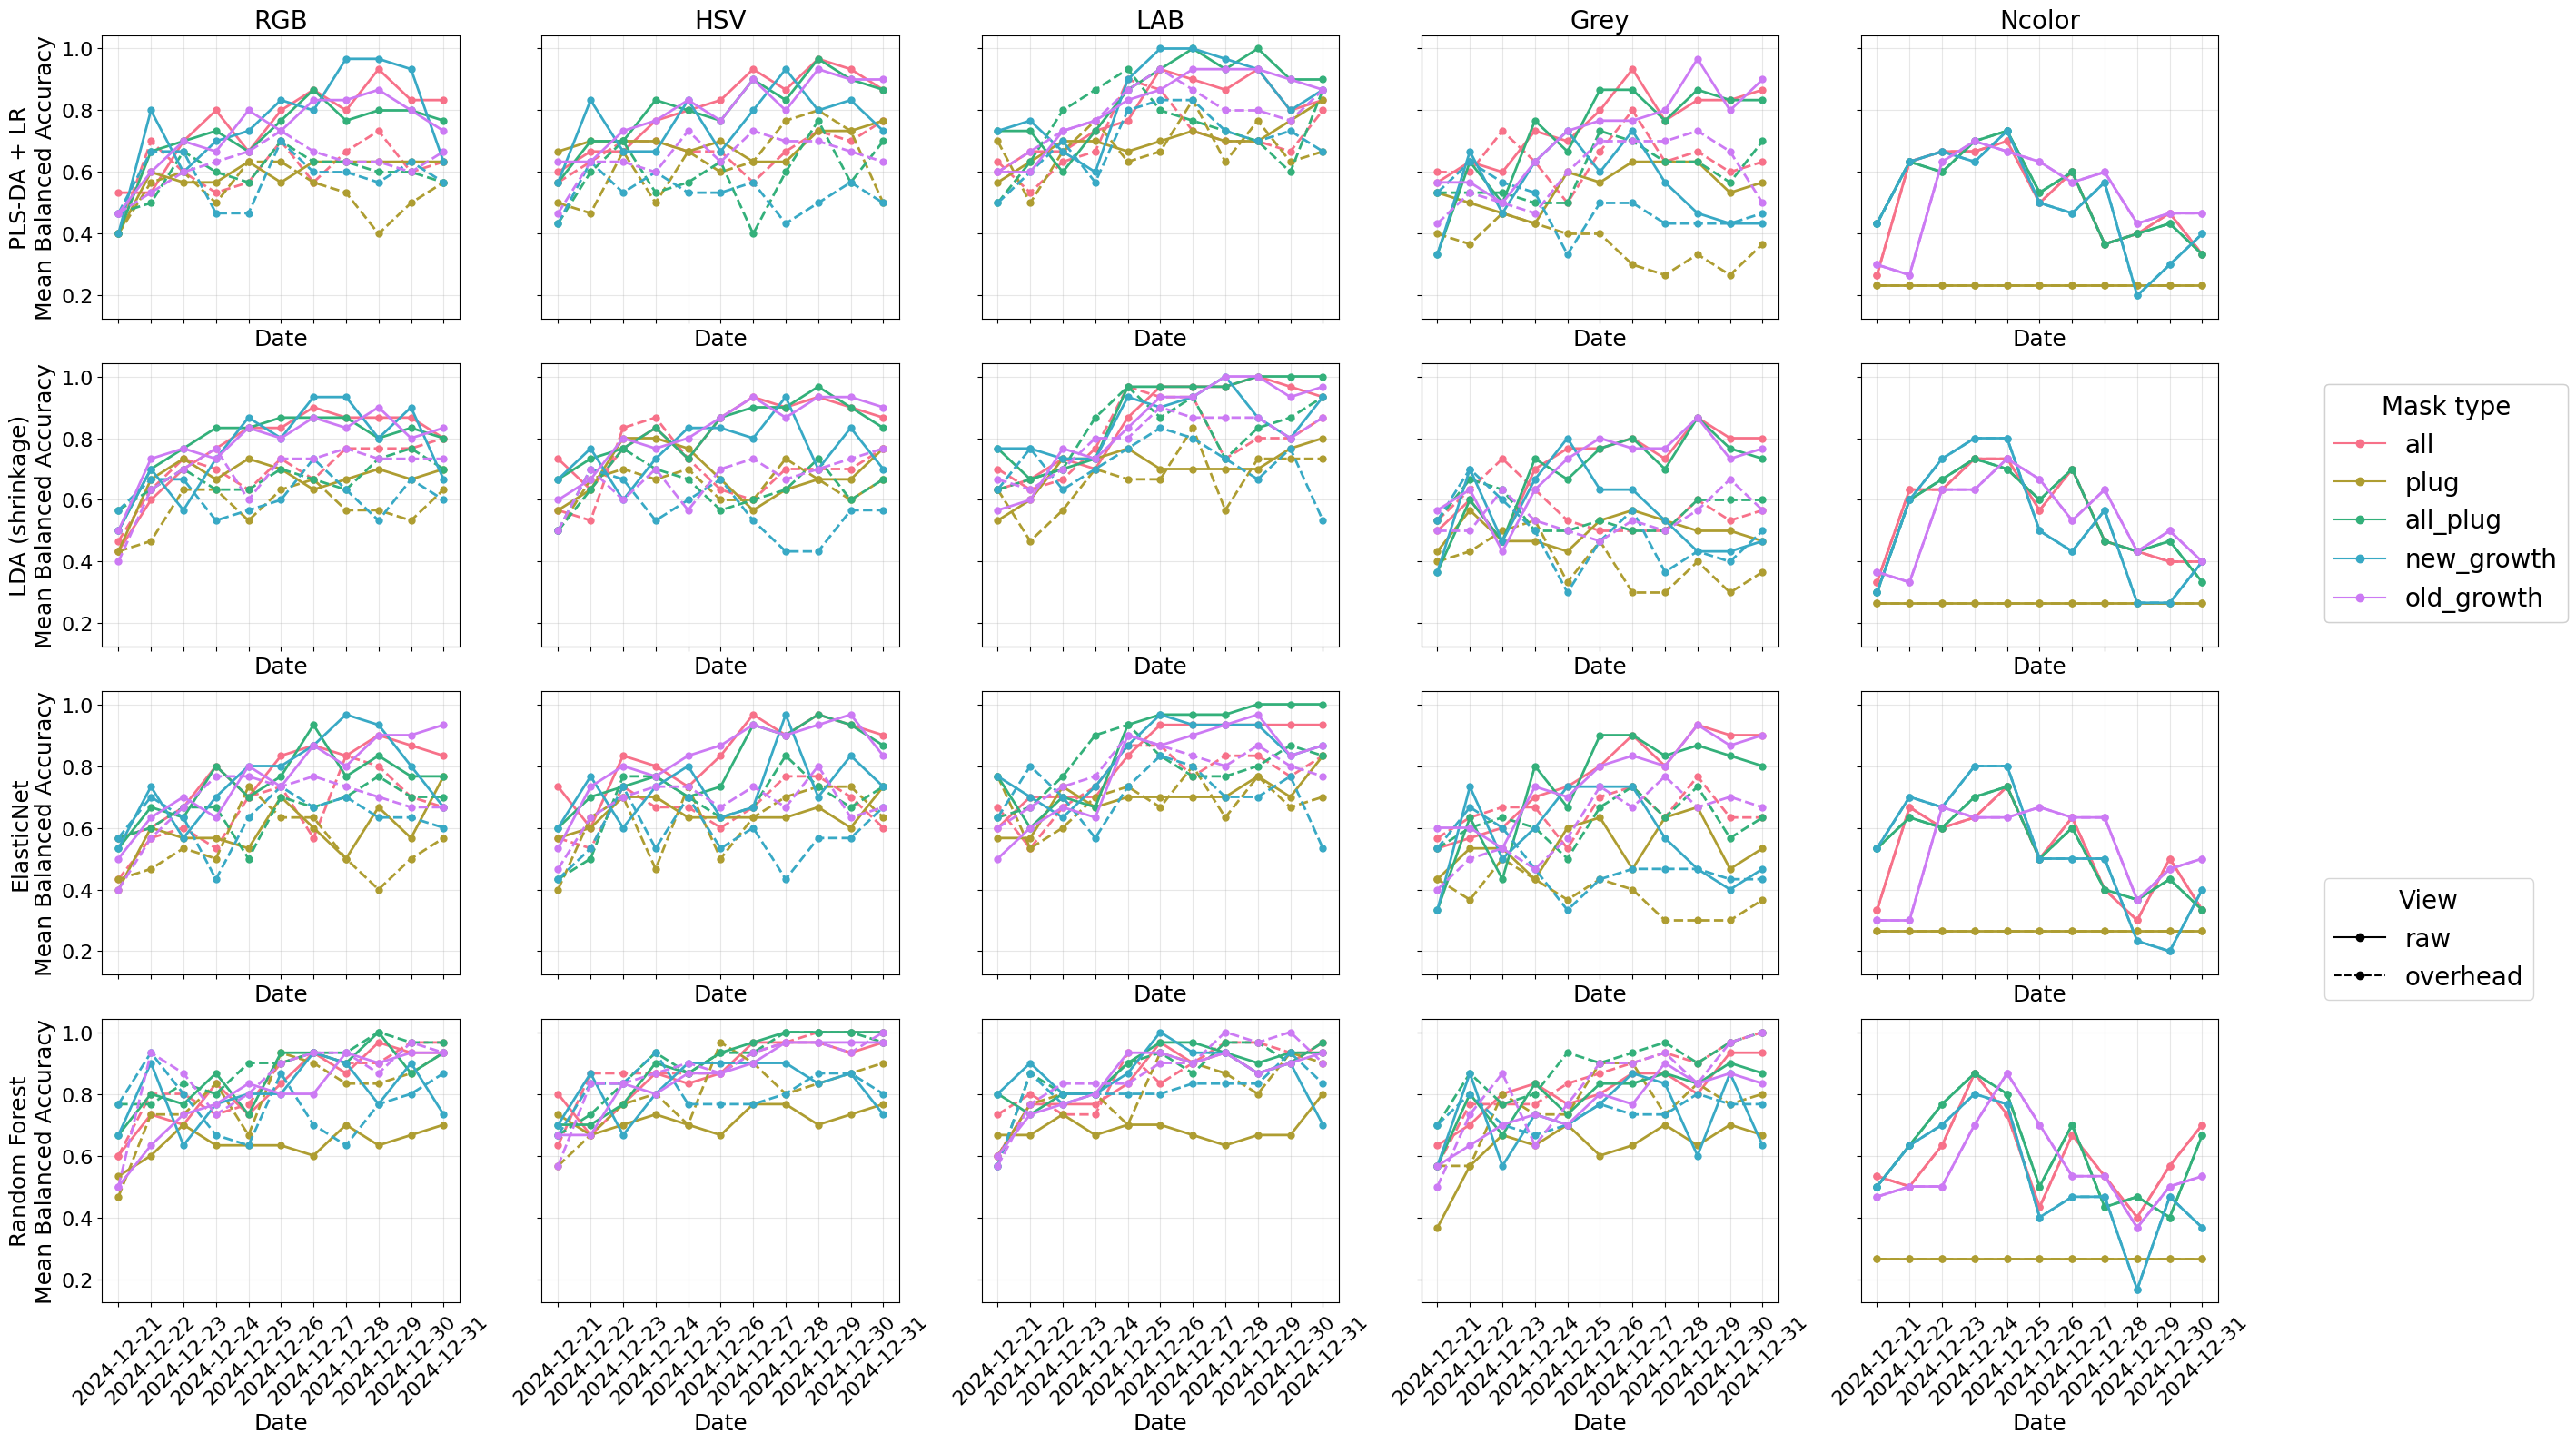

In [40]:
FONTSIZE = 18

fig, axes = plt.subplots(
    n_rows-1, n_cols,
    figsize=(5*n_cols, 4*(n_rows-1)),
    sharex=True,
    sharey=True
)

if n_rows == 1:
    axes = [axes]
if n_cols == 1:
    axes = [[ax] for ax in axes]

legend_handles = {}

for i, model in enumerate(model_order):
    for j, color_type in enumerate(color_types):

        ax = axes[i][j]

        subset = df_scores_nitrogen_class_color[
            (df_scores_nitrogen_class_color["model_label"] == model) &
            (df_scores_nitrogen_class_color["color_space"] == color_type)
        ]

        for mask_type in mask_order:
            mask_subset = subset[subset["mask_type"] == mask_type]

            for view in view_order:
                view_subset = mask_subset[mask_subset["view"] == view]

                if not view_subset.empty:
                    view_subset = view_subset.sort_values("date")

                    line, = ax.plot(
                        view_subset["date"],
                        view_subset["mean_balanced_accuracy"],
                        marker="o",
                        color=mask_palette[mask_type],
                        linestyle=view_linestyles[view],
                        linewidth=2,
                        markersize=5,
                        label=f"{view}-{mask_type}"
                    )

                    key = f"{view}-{mask_type}"
                    if key not in legend_handles:
                        legend_handles[key] = line

        if i == 0:
            ax.set_title(color_type, fontsize=FONTSIZE + 2)

        if j == 0:
            ax.set_ylabel(f"{model}\nMean Balanced Accuracy", fontsize=FONTSIZE)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Date", fontsize=FONTSIZE)
        ax.tick_params(axis='x', rotation=45, labelsize=FONTSIZE - 2)
        ax.tick_params(axis='y', labelsize=FONTSIZE - 2)
        ax.grid(True, alpha=0.3)

mask_legend = [
    Line2D([0], [0], color=mask_palette[m], linestyle='-', marker='o', label=m)
    for m in mask_order
]

view_legend = [
    Line2D([0], [0], color='black', linestyle=view_linestyles[v], marker='o', label=v)
    for v in view_order
]

legend1 = fig.legend(
    handles=mask_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.65),
    title="Mask type",
    fontsize=FONTSIZE+2,
    title_fontsize=FONTSIZE+2
)

legend2 = fig.legend(
    handles=view_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.35),
    title="View",
    fontsize=FONTSIZE+2,
    title_fontsize=FONTSIZE+2
)

fig.add_artist(legend1)

plt.tight_layout()
plt.savefig("../results/nitrogen_class/classification_performance_over_time_nitrogen_color.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [80]:
df_plot_color = df_scores_nitrogen_class_color.copy()
df_plot_color= df_plot_color[(df_plot_color["model"]=="ElasticNet_MultinomialLR")]

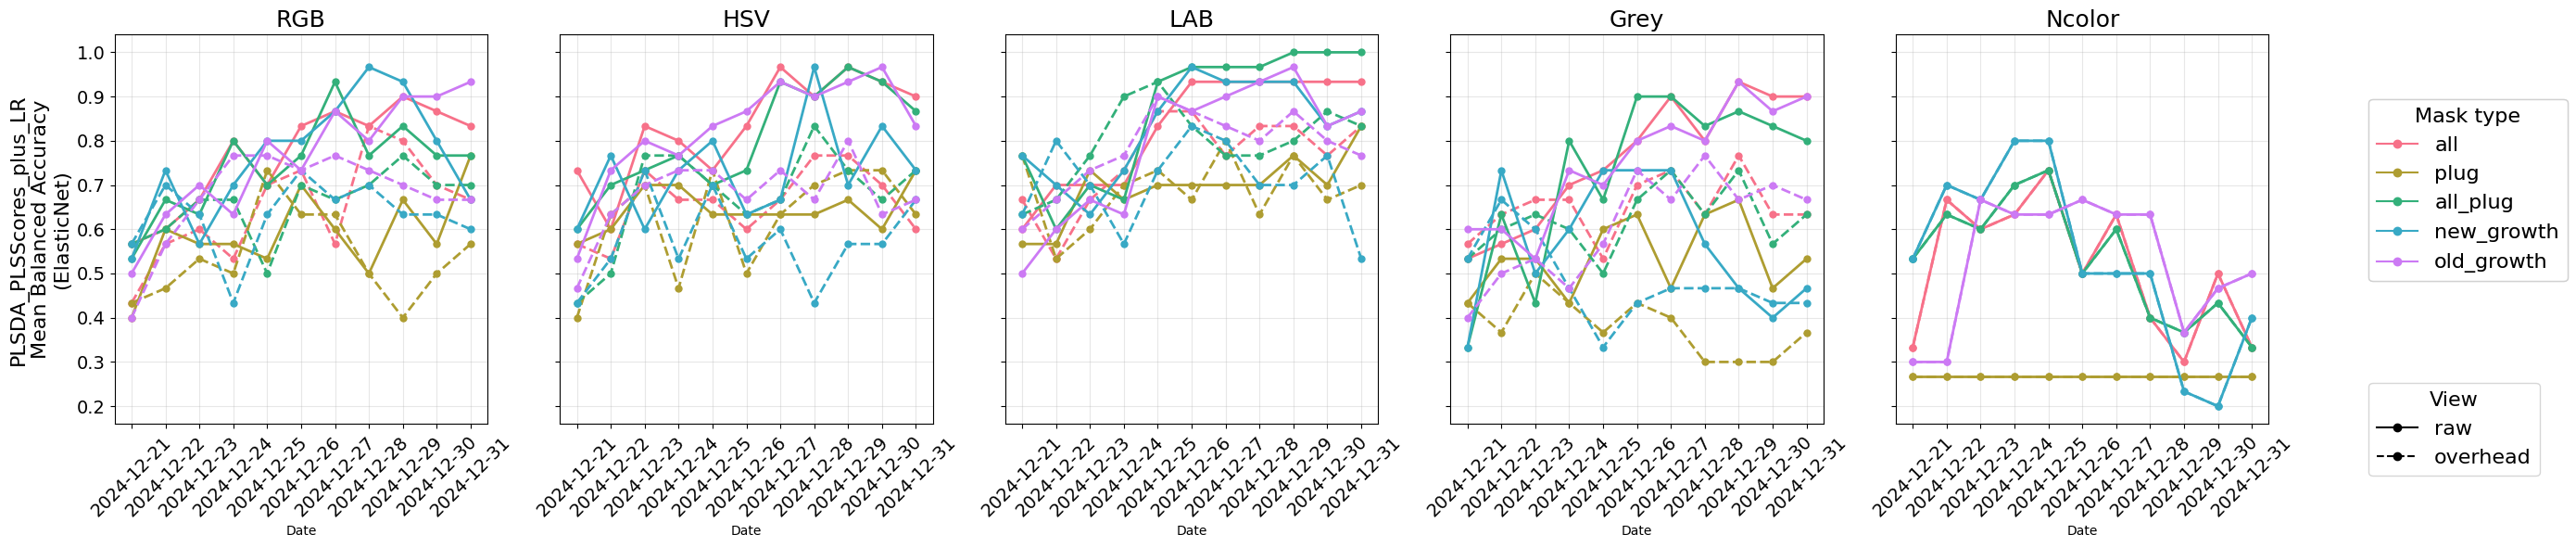

In [81]:
fig, axes = plt.subplots(
    1, n_cols,
    figsize=(5*n_cols, 6*1),
    sharex=True,
    sharey=True
)

if n_cols == 1:
    axes = [axes]

legend_handles = {}

for j, color_type in enumerate(color_types):

    ax = axes[j]

    subset = df_plot_color[
        (df_plot_color["color_space"] == color_type)
    ]

    for mask_type in mask_order:
        mask_subset = subset[subset["mask_type"] == mask_type]

        for view in view_order:
            view_subset = mask_subset[mask_subset["view"] == view]

            if not view_subset.empty:
                view_subset = view_subset.sort_values("date")

                line, = ax.plot(
                    view_subset["date"],
                    view_subset["mean_balanced_accuracy"],
                    marker="o",
                    color=mask_palette[mask_type],
                    linestyle=view_linestyles[view],
                    linewidth=2,
                    markersize=5,
                    label=f"{view}-{mask_type}"
                )

                key = f"{view}-{mask_type}"
                if key not in legend_handles:
                    legend_handles[key] = line
    ax.set_title(color_type, fontsize=FONTSIZE + 2)

    # Row labels on left column
    if j == 0:
        ax.set_ylabel(f"{model}\nMean Balanced Accuracy\n(ElasticNet)", fontsize=FONTSIZE)
    else:
        ax.set_ylabel("")

    ax.set_xlabel("Date")
    ax.tick_params(axis='x', rotation=45, labelsize=FONTSIZE - 2)
    ax.tick_params(axis='y', labelsize=FONTSIZE - 2)
    ax.grid(True, alpha=0.3)

# ---- Mask legend (color only) ----
mask_legend = [
Line2D([0], [0],
        color=mask_palette[m],
        linestyle='-',
        marker='o',
        label=m)
for m in mask_order
]

# ---- View legend (linestyle only) ----
view_legend = [
Line2D([0], [0],
        color='black',
        linestyle=view_linestyles[v],
        marker='o',
        label=v)
for v in view_order
]

legend1 = fig.legend(
handles=mask_legend,
loc="center left",
bbox_to_anchor=(1.02, 0.65),
title="Mask type",fontsize=FONTSIZE, title_fontsize=FONTSIZE
)

legend2 = fig.legend(
handles=view_legend,
loc="center left",
bbox_to_anchor=(1.02, 0.22),
title="View",fontsize=FONTSIZE, title_fontsize=FONTSIZE
)

fig.add_artist(legend1)

plt.tight_layout()
plt.show()

# check elastic net L1 and l2

In [88]:
rows = []
for (view, mask_type, date), v in results_nitrogen_class.items():
    s = v[0].get('ElasticNet_MultinomialLR')   

    df_tmp = s.reset_index()
    
    df_tmp["view"] = view
    df_tmp["mask_type"] = mask_type
    df_tmp["date"] = date

    rows.append(df_tmp)

df_elastic_fold = pd.concat(rows, ignore_index=True)

In [89]:
df_elastic_fold

,index,fold,accuracy,balanced_accuracy,best_clf__C,best_clf__l1_ratio,view,mask_type,date
0,0,1,0.500000,0.500000,3.162278,0.5,overhead,all,2024-12-21
1,1,2,0.666667,0.666667,0.100000,0.1,overhead,all,2024-12-21
2,2,3,0.666667,0.666667,0.100000,0.1,overhead,all,2024-12-21
3,3,4,0.666667,0.666667,3.162278,0.9,overhead,all,2024-12-21
4,4,5,0.333333,0.333333,0.316228,0.3,overhead,all,2024-12-21
...,...,...,...,...,...,...,...,...,...
545,0,1,1.000000,1.000000,0.316228,0.3,raw,old_growth,2024-12-31
546,1,2,0.833333,0.833333,0.100000,0.1,raw,old_growth,2024-12-31
547,2,3,0.833333,0.833333,0.316228,0.1,raw,old_growth,2024-12-31
548,3,4,0.833333,0.833333,0.316228,0.1,raw,old_growth,2024-12-31
